In [245]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy


sys.path.append('..')
import plot_settings
plot_settings.apply()
colors = plot_settings.colors()

# Importing data

In [246]:

def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        delim_whitespace=True,
        comment="%",
        header=None
    )

    df.columns = ['u_par','C','t','E_cell (V)','I_cell (A)','Rx_cell (N)','u_cell (m)','E_ocv_cell (V)']

    # Sort by time within each batch
    df = df.sort_values(["C", "t"])
    return df



path = f'test_data_50beta_20p'

data = read_data(path)

#rename columns
data.columns = ['u_par','C','t','V_t','I','Rx','u','ocv']



/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_23032/1032795895.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [247]:
# Add numeric trajectory id for each unique (C, u_par) pair
data['trajectory_id'] = data.groupby(['C', 'u_par'], sort=True).ngroup()

# Optional lookup table (one row per trajectory)
trajectory_lookup = (
    data[['C', 'u_par', 'trajectory_id']]
    .drop_duplicates()
    .sort_values('trajectory_id')
    .reset_index(drop=True)
)

print(trajectory_lookup)
print(f"Number of trajectories: {trajectory_lookup['trajectory_id'].nunique()}")

      C  u_par  trajectory_id
0   0.7   13.2              0
1   0.8    2.2              1
2   1.1   27.0              2
3   1.3   20.1              3
4   1.4   10.0              4
5   1.8   25.8              5
6   2.0   15.5              6
7   2.3   11.2              7
8   2.3   24.2              8
9   2.6   14.6              9
10  2.8    0.6             10
11  3.2   17.7             11
12  3.3    4.7             12
13  3.6    6.7             13
14  3.7   19.2             14
15  3.9   21.4             15
16  4.2   23.5             16
17  4.3   29.7             17
18  4.7    3.3             18
19  4.9    7.8             19
Number of trajectories: 20


In [248]:
# Add a trajectory column (reuse existing IDs if already available)
if 'trajectory_id' in data.columns:
	data['trajectory'] = data['trajectory_id']
else:
	data['trajectory'] = data.groupby(['C', 'u_par'], sort=True).ngroup()

display(data)

,u_par,C,t,V_t,I,Rx,u,ocv,trajectory_id,trajectory
10542,13.2,0.7,0,4.295441,-3.484751,-1.008673e+09,0.000019,4.324999,0,0
10543,13.2,0.7,2,4.279840,-3.484751,-1.008373e+09,0.000019,4.323816,0,0
10544,13.2,0.7,4,4.271748,-3.484751,-1.008073e+09,0.000019,4.322632,0,0
10545,13.2,0.7,6,4.265244,-3.484751,-1.007773e+09,0.000019,4.321447,0,0
10546,13.2,0.7,8,4.259728,-3.484751,-1.007474e+09,0.000019,4.320263,0,0
...,...,...,...,...,...,...,...,...,...,...
5905,7.8,4.9,560,2.774639,-24.393256,-8.372057e+06,0.000011,3.598965,19,19
5906,7.8,4.9,562,2.734914,-24.393256,-6.273263e+06,0.000011,3.596569,19,19
5907,7.8,4.9,564,2.691822,-24.393256,-4.174469e+06,0.000011,3.594173,19,19
5908,7.8,4.9,566,2.635744,-24.393256,-2.075675e+06,0.000011,3.591777,19,19


# Plotting data

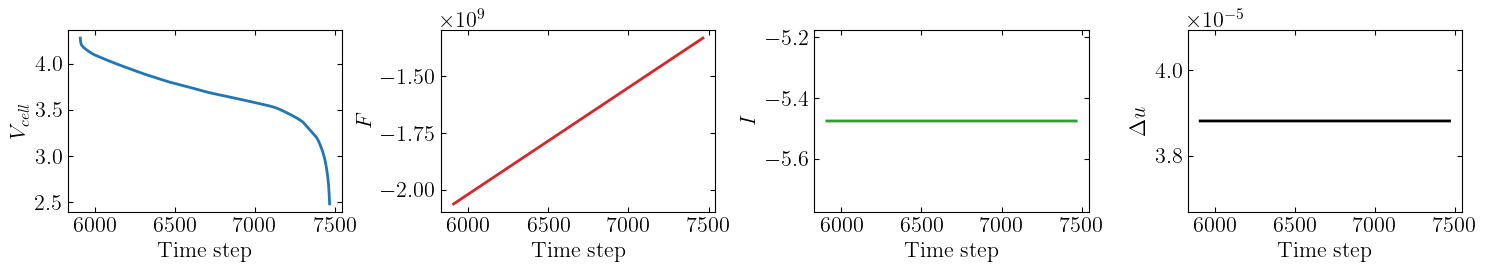

In [249]:

plot_idx = data['trajectory'] == 2
f, ax = plt.subplots(1, 4, figsize=(15, 3))
ax[0].plot(data['V_t'][plot_idx], '-', color = colors[0], lw = 2)
ax[0].set_xlabel('Time step')
ax[0].set_ylabel('$V_{cell}$')
ax[1].plot(data['Rx'][plot_idx], lw = 2,color = colors[1])
ax[1].set_xlabel('Time step')
ax[1].set_ylabel('$F$')
ax[2].plot(data['I'][plot_idx], lw = 2,color = colors[2])
ax[2].set_xlabel('Time step')
ax[2].set_ylabel('$I$')
ax[3].plot(data['u'][plot_idx], lw = 2,color = colors[3])
ax[3].set_xlabel('Time step')
ax[3].set_ylabel(r'$\Delta u$')

plt.tight_layout()
plt.show()

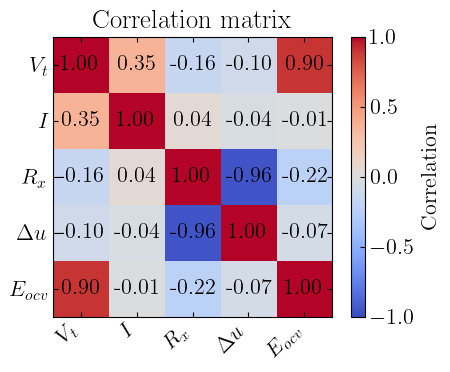

In [250]:
# Correlation matrix for current signals in this batch

X = data[['V_t','I','Rx','u_par','ocv']].values
feature_names = ['$V_t$','$I$','$R_x$',r'$\Delta u$','$E_{ocv}$']
with np.errstate(invalid="ignore", divide="ignore"):
    corr = np.corrcoef(X, rowvar=False)


fig, ax_corr = plt.subplots(figsize=(5, 4))
im = ax_corr.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax_corr.set_xticks(np.arange(len(feature_names)))
ax_corr.set_yticks(np.arange(len(feature_names)))
ax_corr.set_xticklabels(feature_names, rotation=45, ha="right")
ax_corr.set_yticklabels(feature_names)
ax_corr.set_title("Correlation matrix")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax_corr.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax_corr, label="Correlation")
plt.tight_layout()
plt.show()

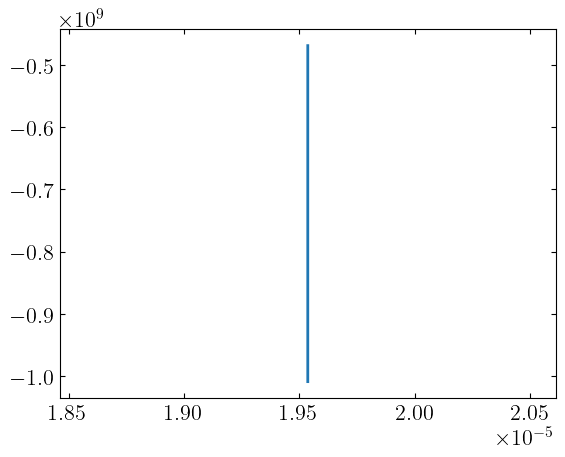

In [251]:

L_tot = 14.8e-5
traj = 0
plt.plot(data['u_par'][data['trajectory'] == traj]* L_tot / 100, data['Rx'][data['trajectory'] == traj], lw = 2, color = colors[0])
groups = data.groupby('u_par')['Rx']


first_rx = data.groupby('u_par')['Rx'].first()
k = -first_rx / (data.groupby('u_par')['u_par'].first() * L_tot / 100)


Text(0, 0.5, '$F$')

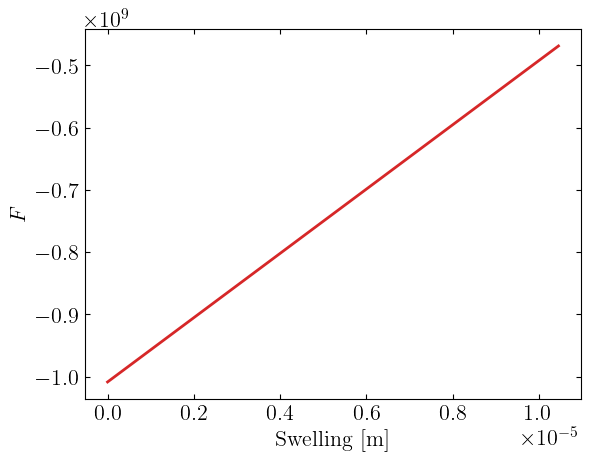

In [252]:
ds = data['Rx'][data['trajectory'] == traj] / k.values[0] + data['u_par'][data['trajectory'] == traj] * L_tot / 100

plt.plot(ds,data['Rx'][data['trajectory'] == traj], lw = 2, color = colors[1])
plt.xlabel('Swelling [m]')
plt.ylabel('$F$')

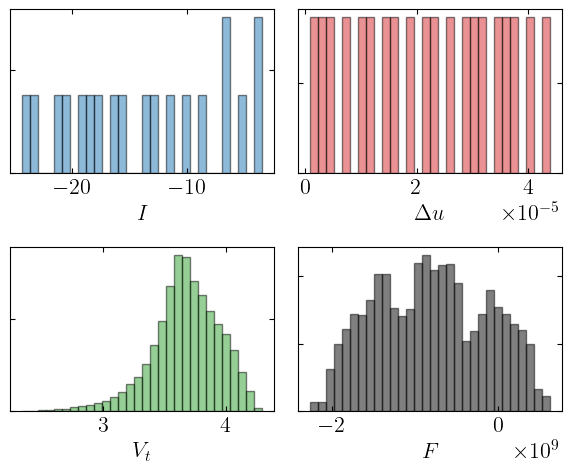

In [253]:
f, ax = plt.subplots(2,2,figsize=(6, 5))

ax[0,0].hist(np.unique(data['I']), bins=30, color=colors[0], alpha=0.5,edgecolor='black',density=True)
ax[0,1].hist(np.unique(data['u_par']) * L_tot / 100, bins=30, color=colors[1], alpha=0.5,edgecolor='black',density=True)
ax[1,0].hist(data['V_t'], bins=30, color=colors[2], alpha=0.5,edgecolor='black',density=True)
ax[1,1].hist(np.unique(data['Rx']), bins=30, color=colors[3], alpha=0.5,edgecolor='black',density=True)
#ax[2,1].hist(np.unique(ds), bins=30, color=colors[4], alpha=0.5,edgecolor='black',density=True)
#ax[2,0].hist(np.unique(data['ocv']), bins=30, color=colors[5], alpha=0.5,edgecolor='black',density=True)
ax[0,0].set_xlabel('$I$')
ax[0,1].set_xlabel(r'$\Delta u$')
ax[1,0].set_xlabel('$V_t$')
ax[1,1].set_xlabel('$F$')
#ax[2,0].set_xlabel('$E_{ocv}$')
#ax[2,1].set_xlabel('$d$')
for a in ax.flat:
    a.set_yticklabels([])
plt.tight_layout()
plt.show()

# Normalizing data

### Characteristics that should be preserved after normalization?


- $\Delta u$: It should primarily be compression, so have a negative sign. 
    - $\Delta u / L$ gives a fractional compression 
- $I$: The sign of it should reflect if we have charge/discharge
    - Maybe just a `standard` normalization on this? 
- $V$: It should always be positive
    - Maybe just a `min-max` normalization on this? 
- $F$: The sign of it should in some way reflect the sign of $\Delta u$. Especially in the cases with low swelling. 
    - Maybe just a `standard` normalization on this? 

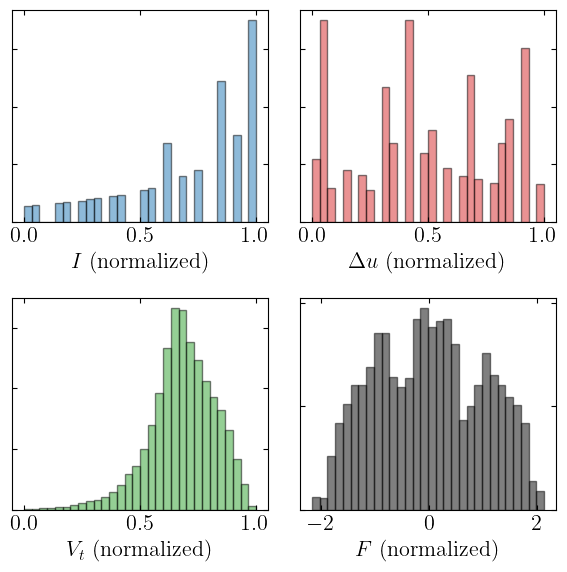

In [254]:
stats = {}

def compute_stats(x, name):
    if name == 'I' or name == 'V_t' or name == 'u_par':
        stats[name] = (np.min(x), np.max(x))
    elif name == 'Rx':
        stats[name] = (np.mean(x), np.std(x))
    return stats[name]
stats['I'] = compute_stats(data['I'], 'I')
stats['V_t'] = compute_stats(data['V_t'], 'V_t')
stats['u_par'] = compute_stats(data['u_par'], 'u_par')
stats['Rx'] = compute_stats(data['Rx'], 'Rx')

def normalize(x, name, stats = stats):
    if name == 'I' or name == 'V_t' or name == 'u_par':
        return (x - stats[name][0]) / (stats[name][1] - stats[name][0])
    elif name == 'Rx':
        return (x - stats[name][0]) / stats[name][1]
    
def denormalize(x, name, stats=stats):
    if name == 'I' or name == 'V_t' or name == 'u_par':
        return x * (stats[name][1] - stats[name][0]) + stats[name][0]
    elif name == 'Rx':
        return x * stats[name][1] + stats[name][0]
    
data['I_norm'] = normalize(data['I'], 'I')
data['V_t_norm'] = normalize(data['V_t'], 'V_t')
data['u_par_norm'] = normalize(data['u_par'], 'u_par')
data['Rx_norm'] = normalize(data['Rx'], 'Rx')

f, ax = plt.subplots(2,2,figsize=(6, 6))
ax[0,0].hist(data['I_norm'], bins=30, color=colors[0], alpha=0.5,edgecolor='black',density=True)
ax[0,1].hist(data['u_par_norm'], bins=30, color=colors[1], alpha=0.5,edgecolor='black',density=True)    
ax[1,0].hist(data['V_t_norm'], bins=30, color=colors[2], alpha=0.5,edgecolor='black',density=True)
ax[1,1].hist(data['Rx_norm'], bins=30, color=colors[3], alpha=0.5,edgecolor='black',density=True)
ax[0,0].set_xlabel('$I$ (normalized)')
ax[0,1].set_xlabel(r'$\Delta u$ (normalized)')
ax[1,0].set_xlabel('$V_t$ (normalized)')
ax[1,1].set_xlabel('$F$ (normalized)')
for a in ax.flat:
    a.set_yticklabels([])
plt.tight_layout()
plt.show()

# Splitting data

- The targets $y_{k+1}$ have to be extracted
    - Ensuring that the targets are within the same trajectory
    - One can check by using a `valid = (traj_id[:-1] == traj_id[1:])`
- Next, they have to matched such that each training-pair has the following form $$(y_{k+1})\sim(y_k,x_k)$$

In [ ]:
N_trajs = len(data['trajectory'].unique())


test_inds = data['trajectory'] >= int(N_trajs *0.8)

print(test_inds.sum(), 'test samples')

X = np.zeros((len(data)-1, 4))
y = np.zeros((len(data)-1,2))
traj_len0 = 0
for i,traj_ids in enumerate(data['trajectory'].unique()):
    traj_len1 = traj_len0 + len(data[data['trajectory'] == traj_ids]) - 1
    X[traj_len0:traj_len1,...] = data[['V_t_norm','Rx_norm','I_norm','u_par_norm']][data['trajectory'] == traj_ids].values[:-1]
    y[traj_len0:traj_len1,...] = data[['V_t_norm','Rx_norm']][data['trajectory'] == traj_ids].values[1:]

    traj_len0 = traj_len1
print(X.shape)

1271 test samples
(15405, 4)


In [256]:

print(f"Number of trajectories: {N_trajs}")


Number of trajectories: 20


In [257]:

#valid = (traj_id[:-1] == traj_id[1:])
#idx = torch.where(valid)[0]

x_np = data[['I_norm','u_par_norm']].values
y_np = data[['V_t_norm','Rx_norm']].values

x_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

split = (data['trajectory']< int(N_trajs *0.8)).sum()

def _split_flat(arr, split = split):
    return arr[:split], arr[split:]   # Same as reshape(B * T, C)    # (B*T, 4)

x_train, x_test = _split_flat(x_tensor); y_train, y_test = _split_flat(y_tensor)

print(f'X shape {x_tensor.shape}\ty shape {y_tensor.shape}\nX-train shape: {x_train.shape}\ty-train shape: {y_train.shape}\nX-test shape: {x_test.shape}\ty-test shape: {y_test.shape}')



train_loader_flat = DataLoader(TensorDataset(x_train, y_train), batch_size=int(len(data) / 8) , shuffle=True)

X shape torch.Size([15405, 4])	y shape torch.Size([15405, 2])
X-train shape: torch.Size([14135, 4])	y-train shape: torch.Size([14135, 2])
X-test shape: torch.Size([1270, 4])	y-test shape: torch.Size([1270, 2])


# Defining model

Inputs: $I_t$, $\Delta u_t$, $V_t$, $F_t$

Outputs $\dot{V}_t$, $\dot{F}_t$

Employing a NODE setup, with the state variable $\xi = [V,F]$, we get $$\dot{\xi}=f_{NN}(I_t,\Delta u_t,\xi)\Rightarrow \xi(t) = \int_0^tf_{NN}(I_t,\Delta u_t,\xi)\,\mathrm{d}t$$

In [258]:
''' Mk 1 '''
class Net(nn.Module):
    def __init__(self, input_size=4, hidden_size=256): 
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2)   # output size is 2 for (V_cell, F)
        )
    
    # def forward(self, x):
    #     x = self.net(x)
    #     return x
    def forward(self, input, PE = False):
        if PE:
            pass
        else:
            return self.net(input)
    
model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [259]:
summary(model, input_data=x_train[:2])

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [2, 2]                    --
├─Sequential: 1-1                        [2, 2]                    --
│    └─Linear: 2-1                       [2, 256]                  1,280
│    └─ReLU: 2-2                         [2, 256]                  --
│    └─Linear: 2-3                       [2, 256]                  65,792
│    └─ReLU: 2-4                         [2, 256]                  --
│    └─Linear: 2-5                       [2, 2]                    514
Total params: 67,586
Trainable params: 67,586
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.14
Input size (MB): 0.25
Forward/backward pass size (MB): 0.01
Params size (MB): 0.27
Estimated Total Size (MB): 0.53

# Training
Since we only have values for $V_t$ and $F_t$, we need to add a torch-compatible integrator within the training procedure. For starters, we use the simple Euler forward, yielding the following loss $$\mathcal{L} = \|\xi_t-f_{NN}(x_t)\Delta t\|^2_2\quad x_t = [I_t,\Delta u_t].$$
After training, the model could in principle be used in your favorite integrator. 

In [ ]:
def next_step(dy,X, dt = 2, stats = stats):
    y = X[:,:2]
    V = denormalize(y[:,0], 'V_t', stats)

    F = denormalize(y[:,1], 'Rx', stats)
    V1 = V + dy[:,0] * dt
    F1 = F + dy[:,1] * dt
    y1 = torch.zeros_like(y)
    y1[:,0] = normalize(V1, 'V_t',stats)
    y1[:,1] = normalize(F1, 'Rx',stats)
    y1 = dy * dt + y
    return y1


    

def training(epochs=30, PE = True):
    history = {"loss": [], "d_loss": [], "p_loss": [], "time per ep": []}
    for ep in range(epochs):
        model.train()
        tot_ep_loss = 0.0
        d_ep_loss = 0.0
        start_t = time.perf_counter()
        for x_b, y_b in train_loader_flat:
            # print('batch shapes:', x_b.shape, y_b.shape, mask_b.shape)
            dy = model(x_b, PE=PE) 
            y_pred = next_step(dy,x_b)
            d_loss = nn.MSELoss()(y_pred, y_b)
            tot_loss = d_loss
            # print('pred shapes:', pred.shape)
            optimizer.zero_grad()
            tot_loss.backward()
            optimizer.step()
            tot_ep_loss += d_loss.item()
            d_ep_loss += d_loss.item()
        tot_last = tot_ep_loss / len(train_loader_flat)  # Average loss per batch
        d_last = d_ep_loss / len(train_loader_flat)
        end_t = time.perf_counter()

        history["loss"].append(tot_last)
        history["d_loss"].append(d_last)
        history["time per ep"].append(end_t - start_t)
        if ep == 0:
            print(f'ETA: {(end_t - start_t) * epochs / 60:.2f} min')
        print(f"Epoch {ep+1} | loss {tot_last:.3e} | time {end_t - start_t:.2f}s")

    return history

In [261]:
history = training(epochs=250, PE=False)

ETA: 0.32 min
Epoch 1 | loss 1.589e-02 | time 0.08s
Epoch 2 | loss 5.054e-03 | time 0.27s
Epoch 3 | loss 1.686e-03 | time 0.07s
Epoch 4 | loss 6.580e-04 | time 0.07s
Epoch 5 | loss 4.362e-04 | time 0.07s
Epoch 6 | loss 1.426e-04 | time 0.07s
Epoch 7 | loss 8.964e-05 | time 0.07s
Epoch 8 | loss 4.095e-05 | time 0.08s
Epoch 9 | loss 2.661e-05 | time 0.08s
Epoch 10 | loss 1.415e-05 | time 0.08s
Epoch 11 | loss 1.116e-05 | time 0.08s
Epoch 12 | loss 8.158e-06 | time 0.07s
Epoch 13 | loss 6.591e-06 | time 0.08s
Epoch 14 | loss 5.804e-06 | time 0.08s
Epoch 15 | loss 5.055e-06 | time 0.08s
Epoch 16 | loss 4.700e-06 | time 0.07s
Epoch 17 | loss 4.239e-06 | time 0.07s
Epoch 18 | loss 3.905e-06 | time 0.07s
Epoch 19 | loss 3.749e-06 | time 0.08s
Epoch 20 | loss 3.421e-06 | time 0.08s
Epoch 21 | loss 3.229e-06 | time 0.27s
Epoch 22 | loss 3.152e-06 | time 0.07s
Epoch 23 | loss 2.932e-06 | time 0.07s
Epoch 24 | loss 2.854e-06 | time 0.07s
Epoch 25 | loss 2.701e-06 | time 0.07s
Epoch 26 | loss 2.63

7.023763473057443e-07


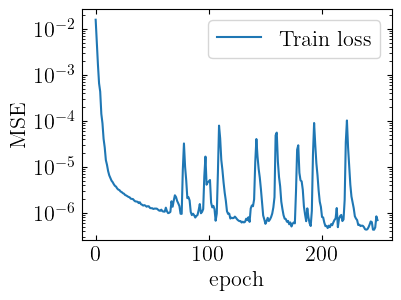

In [262]:
#model_name = 'Second_PENN_ReLU'
#PENN_exp_log.exp_log(model, history, current = currents,name=model_name, d_loss_type = 'mse')
#torch.save(model.state_dict(), f'models/{model_name}_{currents}.pth')
print(history['loss'][-1])
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 3))
ax1.semilogy(history["loss"], label="Train loss")
# ax1.set_yscale("log")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE")
ax1.legend()

In [284]:
from scipy.interpolate import interp1d

def denorm_y(y, stats=stats):
    V = denormalize(y[:,0], 'V_t', stats)
    F = denormalize(y[:,1], 'Rx', stats)
    return np.stack([V, F], axis=1)



#plt.plot(data['V_t'][data['trajectory'] == 16], '-', color = colors[0], lw = 2)

x_init = data[['V_t_norm','Rx_norm','I_norm','u_par_norm']][data['trajectory'] == 17].values[0]

def rollout(model, x_init, steps=1000, PE=False, dt = 2):
    traj = np.zeros((steps, 2))
    X = torch.tensor(x_init, dtype=torch.float32)
    y0 = X[:2].numpy()
    traj[0] = y0
    for t in range(1, steps):
        with torch.no_grad():
            dy = model(X, PE=PE)
            y1 = dy * dt + X[:2]
            X = torch.cat([y1, X[2:]], dim=-1)             
            traj[t] = y1.numpy()
    return traj

traj_pred = rollout(model, x_init, steps=400, PE=False)
print(denorm_y(traj_pred))

[[ 4.15614823e+00 -2.26951124e+09]
 [ 4.13544977e+00 -2.27442315e+09]
 [ 4.11693583e+00 -2.27921491e+09]
 [ 4.10055927e+00 -2.28380717e+09]
 [ 4.08616700e+00 -2.28818339e+09]
 [ 4.07355031e+00 -2.29236799e+09]
 [ 4.06246743e+00 -2.29641606e+09]
 [ 4.05278616e+00 -2.30036743e+09]
 [ 4.04437328e+00 -2.30423479e+09]
 [ 4.03710044e+00 -2.30802506e+09]
 [ 4.03085223e+00 -2.31174448e+09]
 [ 4.02550827e+00 -2.31540962e+09]
 [ 4.02095547e+00 -2.31903171e+09]
 [ 4.01698688e+00 -2.32262810e+09]
 [ 4.01356117e+00 -2.32619943e+09]
 [ 4.01064043e+00 -2.32974619e+09]
 [ 4.00818885e+00 -2.33326885e+09]
 [ 4.00617340e+00 -2.33676790e+09]
 [ 4.00474027e+00 -2.34023322e+09]
 [ 4.00391059e+00 -2.34367300e+09]
 [ 4.00363267e+00 -2.34708724e+09]
 [ 4.00386486e+00 -2.35046599e+09]
 [ 4.00455033e+00 -2.35380618e+09]
 [ 4.00564252e+00 -2.35710847e+09]
 [ 4.00710213e+00 -2.36037349e+09]
 [ 4.00889334e+00 -2.36360188e+09]
 [ 4.01098369e+00 -2.36679478e+09]
 [ 4.01336784e+00 -2.36996648e+09]
 [ 4.01602057e+00 -2

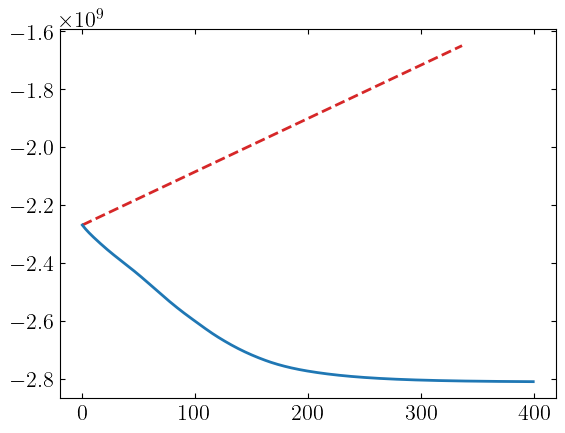

In [286]:
plt.plot(data['Rx'][data['trajectory'] == 17].values, '--', color = colors[1], lw = 2, label='True')
plt.plot(denorm_y(traj_pred)[:,1], '-', color = colors[0], lw = 2, label='Predicted')

In [125]:

I_interp = interp1d(t_, X_run[], axis=0, fill_value="extrapolate")
u_interp = interp1d(t_, u_, axis=0, fill_value="extrapolate")

def x_of_t(t):
    return np.concatenate([I_interp(t), u_interp(t)])



def n_ode(y, t, model, x_of_t):
    # y: numpy array, shape (d_y,)
    # x_of_t(t): returns numpy array, shape (d_x,)

    y_torch = torch.tensor(y, dtype=torch.float32).unsqueeze(0)

    x_t = x_of_t(t)
    x_torch = torch.tensor(x_t, dtype=torch.float32).unsqueeze(0)

    with torch.no_grad():
        dy = model(y_torch, x_torch)   # shape (1, d_y)

    return dy.squeeze(0).cpu().numpy()


y = scipy.integrate.odeint(n_ode, x_test[0].numpy(), t_, args=(model,))

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2169755381.py, line 1)